In [1]:
import xarray as xr
import earthkit.data
import earthkit.plots
import earthkit.regrid
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

/home/ubuntu/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
request = {
     'activity': 'ScenarioMIP',
     'class': 'd1',
     'dataset': 'climate-dt',
     'date': '20200101',
     'experiment': 'SSP3-7.0',
     'expver': '0001',
     'generation': '1',
     'levtype': 'sfc',
     'model': 'IFS-NEMO',
     'param': '263000',
     'realization': '1',
     'resolution': 'standard',
     'stream': 'clte',
     'time': '0000', # '0100/0200/0300/0400/0500/0600'
     'type': 'fc'
 }

In [4]:
# Base request template
request_silvl = {
    'activity': 'ScenarioMIP',
    'class': 'd1',
    'dataset': 'climate-dt',
    'date': '20200101/to/20200102',
    'experiment': 'SSP3-7.0',
    'expver': '0001',
    'generation': '1',
    'levtype': 'o2d',
    'model': 'IFS-NEMO',
    'param': '263000',
    'realization': '1',
    'resolution': 'high',
    'stream': 'clte',
    'time': '0000',
    'type': 'fc'
}

In [5]:
data = earthkit.data.from_source("polytope", "destination-earth", request_silvl, address="polytope.lumi.apps.dte.destination-earth.eu", stream=False)

2025-02-18 13:53:12 - INFO - Key read from /home/ubuntu/.polytopeapirc
2025-02-18 13:53:12 - INFO - Sending request...
{'request': 'activity: ScenarioMIP\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            'date: 20200101/to/20200102\n'
            'experiment: SSP3-7.0\n'
            "expver: '0001'\n"
            "generation: '1'\n"
            'levtype: o2d\n'
            'model: IFS-NEMO\n'
            "param: '263000'\n"
            "realization: '1'\n"
            'resolution: high\n'
            'stream: clte\n'
            "time: '0000'\n"
            'type: fc\n',
 'verb': 'retrieve'}
2025-02-18 13:53:12 - INFO - Polytope user key found in session cache for user ubuntu
2025-02-18 13:53:13 - INFO - Request accepted. Please poll ./e1351762-7957-4e1b-9407-318e701ce4e5 for status
2025-02-18 13:53:13 - INFO - Polytope user key found in session cache for user ubuntu
2025-02-18 13:53:13 - INFO - Checking request status (./e1351762-7957-4e1b-9407-318e701ce4e5)

e1351762-7957-4e1b-9407-318e701ce4e5.grib:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

In [6]:
ds = data.to_xarray()

From version 0.11.0 the default engine for to_xarray is 'earthkit'. Use engine=`cfgrib` to invoke the cfgrib engine.


In [10]:
ds

<xarray.Dataset> Size: 403MB
Dimensions:                  (forecast_reference_time: 2, values: 12582912)
Coordinates:
  * forecast_reference_time  (forecast_reference_time) datetime64[ns] 16B 202...
    latitude                 (values) float64 101MB ...
    longitude                (values) float64 101MB ...
Dimensions without coordinates: values
Data variables:
    avg_sithick              (forecast_reference_time, values) float64 201MB ...
Attributes: (12/14)
    param:          avg_sithick
    standard_name:  unknown
    long_name:      Time-mean sea ice thickness
    paramId:        263000
    class:          d1
    stream:         clte
    ...             ...
    expver:         0001
    date:           20200101
    time:           0
    domain:         g
    Conventions:    CF-1.8
    institution:    ECMWF

In [37]:
print(ds.dims)

FrozenMappingWarningOnValuesAccess({'forecast_reference_time': 2, 'values': 12582912})


In [23]:
# Step 1: Assign 'latitude' and 'longitude' as new dimensions for the data
ds = ds.assign_coords({
    'latitude': ('values', ds['latitude'].values),
    'longitude': ('values', ds['longitude'].values),
})

# Check the dataset
print(ds)


<xarray.Dataset> Size: 403MB
Dimensions:                  (forecast_reference_time: 2, values: 12582912)
Coordinates:
  * forecast_reference_time  (forecast_reference_time) datetime64[ns] 16B 202...
    latitude                 (values) float64 101MB 0.0373 0.0746 ... -0.0373
    longitude                (values) float64 101MB 45.0 45.04 ... 315.0 315.0
Dimensions without coordinates: values
Data variables:
    avg_sithick              (forecast_reference_time, values) float64 201MB ...
Attributes: (12/14)
    param:          avg_sithick
    standard_name:  unknown
    long_name:      Time-mean sea ice thickness
    paramId:        263000
    class:          d1
    stream:         clte
    ...             ...
    expver:         0001
    date:           20200101
    time:           0
    domain:         g
    Conventions:    CF-1.8
    institution:    ECMWF


In [38]:
ds = ds.assign_coords(
    longitude=("longitude", ds.lon_temp.values),
    latitude=("latitude", ds.lat_temp.values)
).rename(forecast_reference_time = 'time')

AttributeError: 'Dataset' object has no attribute 'lon_temp'

In [35]:
ds = data.to_xarray()

In [34]:
# Step 1: Convert avg_sithick into a DataArray with the correct dimensions.
# First, ensure we are referencing the correct variable in the dataset
avg_sithick_data = ds['avg_sithick'].values

# Step 2: Drop the 'values' dimension but keep the variable data
ds = ds.drop_dims('values')

# Step 3: Reassign 'avg_sithick' with the new dimensions: 'time', 'latitude', 'longitude'
ds['avg_sithick'] = (['time', 'latitude', 'longitude'], avg_sithick_data)

# Step 4: Add latitude and longitude as coordinates
ds = ds.assign_coords(
    latitude=('latitude', ds['latitude'].values),
    longitude=('longitude', ds['longitude'].values)
)

# Check the result
print(ds)


KeyError: "No variable named 'avg_sithick'. Variables on the dataset include ['time', 'latitude', 'longitude']"

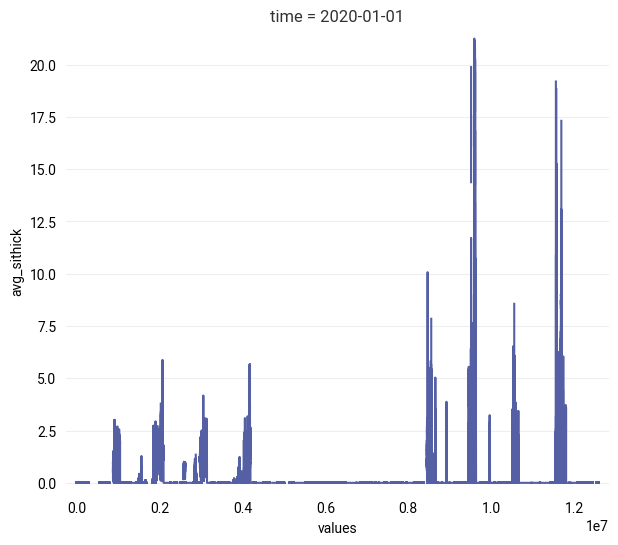

In [41]:
ds.isel(time=0).avg_sithick.plot()

In [43]:
print(ds.dims)

FrozenMappingWarningOnValuesAccess({'time': 141, 'values': 12582912, 'longitude': 12582912, 'latitude': 12582912})


In [34]:
ds

<xarray.Dataset> Size: 293MB
Dimensions:      (time: 141, latitude: 361, longitude: 720)
Coordinates:
  * time         (time) datetime64[ns] 1kB 2020-01-01 2020-01-02 ... 2020-05-20
  * latitude     (latitude) float64 3kB 90.0 89.5 89.0 ... -89.0 -89.5 -90.0
  * longitude    (longitude) float64 6kB 0.0 0.5 1.0 1.5 ... 358.5 359.0 359.5
Data variables:
    avg_sithick  (time, latitude, longitude) float64 293MB ...
Attributes: (12/13)
    param:          avg_sithick
    standard_name:  unknown
    long_name:      Time-mean sea ice thickness
    paramId:        263000
    class:          d1
    stream:         clte
    ...             ...
    type:           fc
    expver:         0001
    date:           20200101
    time:           0
    Conventions:    CF-1.8
    institution:    ECMWF

In [35]:
ds.longitude

<xarray.DataArray 'longitude' (longitude: 720)> Size: 6kB
array([  0. ,   0.5,   1. , ..., 358.5, 359. , 359.5])
Coordinates:
  * longitude  (longitude) float64 6kB 0.0 0.5 1.0 1.5 ... 358.5 359.0 359.5
Attributes:
    units:          degrees_east
    standard_name:  longitude
    long_name:      longitude

In [11]:
out_grid = {"grid": [0.1,0.1]}
r = earthkit.regrid.interpolate(icethic, out_grid=out_grid, method="linear")
d = r.data()
lat = d[0]
lon = d[1]
vals = d[2:]
lat.shape, lon.shape, vals.shape

NameError: name 'icethic' is not defined

In [8]:
ds = r.to_xarray()
ds

<xarray.Dataset> Size: 52MB
Dimensions:      (latitude: 1801, longitude: 3600)
Coordinates:
  * latitude     (latitude) float64 14kB 90.0 89.9 89.8 ... -89.8 -89.9 -90.0
  * longitude    (longitude) float64 29kB 0.0 0.1 0.2 0.3 ... 359.7 359.8 359.9
Data variables:
    avg_sithick  (latitude, longitude) float64 52MB ...
Attributes: (12/13)
    param:          avg_sithick
    standard_name:  unknown
    long_name:      Time-mean sea ice thickness
    paramId:        263000
    class:          d1
    stream:         clte
    ...             ...
    type:           fc
    expver:         0001
    date:           20200101
    time:           0
    Conventions:    CF-1.8
    institution:    ECMWF

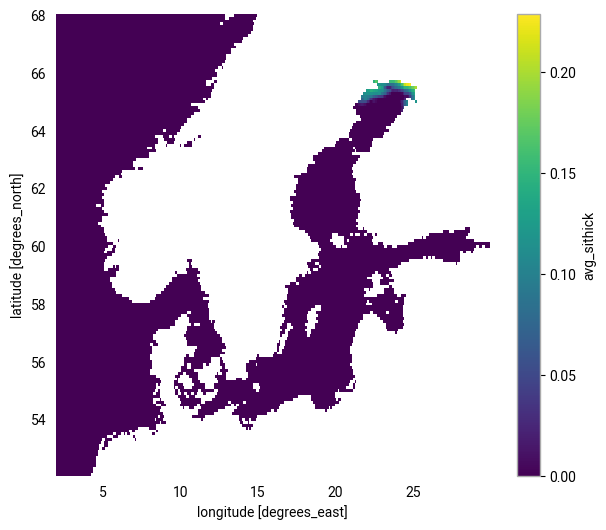

In [23]:
ds.avg_sithick.isel(latitude=slice(220,380)).isel(longitude=slice(20,300)).plot()

In [ ]:
ax = plt.axes(projection=ccrs.PlateCarree())
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.Stereographic(central_latitude=50, central_longitude=50, false_easting=80, false_northing=40)},)
ax.pcolormesh(lon, lat, vals[60,:,:], transform=ccrs.PlateCarree())